# 00 - Setup del dataset EuroSAT

En este notebook se realiza la preparación inicial del dataset EuroSAT para el Trabajo 1 de Inteligencia Computacional.

Objetivos:
- comprobar la carga correcta del dataset,
- analizar sus clases y distribución,
- crear un subconjunto balanceado de 1000 imágenes por clase,
- generar particiones de entrenamiento, validación y prueba,
- construir los DataLoaders base para los experimentos posteriores.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from collections import Counter                             ``

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)

PROJECT_ROOT: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\ic-trabajo1-eurosat
SRC_PATH: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\ic-trabajo1-eurosat\src


In [3]:
from data_utils import (
    resolve_data_dir,
    get_dataset_summary,
    create_balanced_splits,
    load_splits,
    create_dataloaders_from_splits,
    set_seed
)

## Fija la semilla y ruta del dataset

In [4]:
SEED = 42
set_seed(SEED)

DATA_DIR = PROJECT_ROOT.parent / "datasets" / "EuroSAT"
print("Ruta del dataset:", DATA_DIR)
print("¿Existe la carpeta?:", DATA_DIR.exists())

Ruta del dataset: C:\Personales\UPNA\2025-2026\Inteligencia Computacional\recursos 2026\trabajos\datasets\EuroSAT
¿Existe la carpeta?: True


## Resumen general del dataset

In [5]:
summary = get_dataset_summary(data_dir=DATA_DIR)

print("Número total de imágenes:", summary["total_images"])
print("Número de clases:", summary["num_classes"])
print("Clases:", summary["classes"])

Número total de imágenes: 27000
Número de clases: 10
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Distribución por clase en tabla

In [6]:
df_summary = pd.DataFrame(summary["per_class"])
df_summary

,class_name,class_idx,num_images
0,AnnualCrop,0,3000
1,Forest,1,3000
2,HerbaceousVegetation,2,3000
3,Highway,3,2500
4,Industrial,4,2500
5,Pasture,5,2000
6,PermanentCrop,6,2500
7,Residential,7,3000
8,River,8,2500
9,SeaLake,9,3000


## Gráfico de distribución por clase

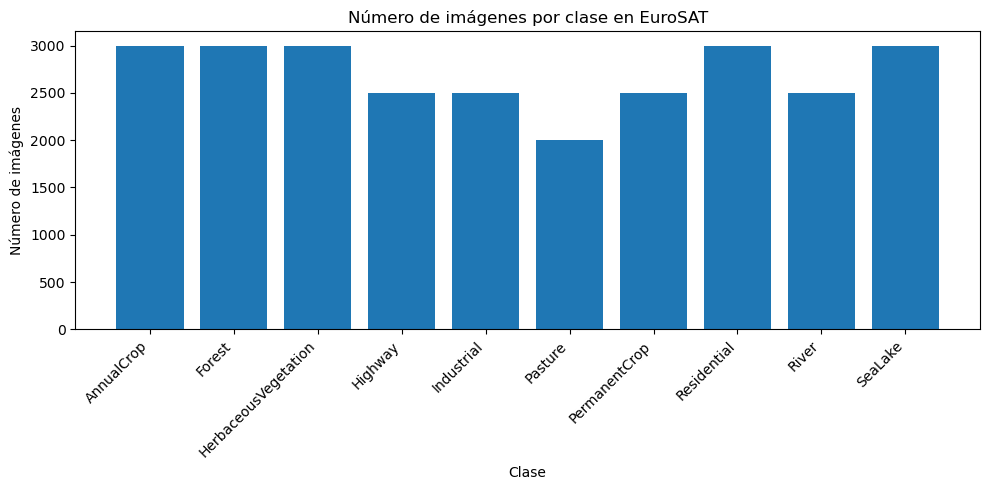

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(df_summary["class_name"], df_summary["num_images"])
plt.xticks(rotation=45, ha="right")
plt.title("Número de imágenes por clase en EuroSAT")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.tight_layout()
plt.show()

## Creando el subconjunto balanceado y splits

In [8]:
split_info = create_balanced_splits(
    data_dir=DATA_DIR,
    subset_per_class=1000,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    seed=SEED
)

In [9]:
print("Imágenes en el subconjunto balanceado:", len(split_info["subset_indices"]))
print("Train:", len(split_info["train_indices"]))
print("Validation:", len(split_info["val_indices"]))
print("Test:", len(split_info["test_indices"]))

Imágenes en el subconjunto balanceado: 10000
Train: 6999
Validation: 1500
Test: 1501


## Distribución del subconjunto

In [10]:
df_subset_counts = pd.DataFrame({
    "class_name": list(split_info["subset_counts"].keys()),
    "subset_count": list(split_info["subset_counts"].values()),
    "train_count": list(split_info["train_counts"].values()),
    "val_count": list(split_info["val_counts"].values()),
    "test_count": list(split_info["test_counts"].values())
})

df_subset_counts

,class_name,subset_count,train_count,val_count,test_count
0,AnnualCrop,1000,700,150,150
1,Forest,1000,700,150,150
2,HerbaceousVegetation,1000,700,150,150
3,Highway,1000,700,150,150
4,Industrial,1000,700,150,150
5,Pasture,1000,700,150,150
6,PermanentCrop,1000,699,150,151
7,Residential,1000,700,150,150
8,River,1000,700,150,150
9,SeaLake,1000,700,150,150


## Cargar los splits desde JSON (prueba de reutilización)

Esta celda prueba que:

- los splits se guardaron bien,
- y se pueden reutilizar en otros notebooks.

In [11]:
loaded_splits = load_splits()
print("Archivo de splits cargado correctamente.")
print("Clases:", loaded_splits["class_names"])

Archivo de splits cargado correctamente.
Clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Creando los dataloaders base

Aquí estamos construyendo los primeros DataLoader para la línea baseline:

- tamaño 64x64, porque EuroSAT ya es pequeño,
- sin augmentation todavía,
- sin normalización ImageNet todavía,
- porque esta primera versión es para la CNN desde cero.

In [12]:
dataloaders, loader_info = create_dataloaders_from_splits(
    split_info=loaded_splits,
    data_dir=DATA_DIR,
    image_size=64,
    batch_size=32,
    num_workers=0,
    use_augmentation=False,
    normalize_with_imagenet=False
)

loader_info

{'classes': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_to_idx': {'AnnualCrop': 0,
  'Forest': 1,
  'HerbaceousVegetation': 2,
  'Highway': 3,
  'Industrial': 4,
  'Pasture': 5,
  'PermanentCrop': 6,
  'Residential': 7,
  'River': 8,
  'SeaLake': 9},
 'image_size': 64,
 'batch_size': 32,
 'num_workers': 0,
 'use_augmentation': False,
 'normalize_with_imagenet': False,
 'n_train': 6999,
 'n_val': 1500,
 'n_test': 1501}

In [13]:
images, labels = next(iter(dataloaders["train"]))

print("Forma del batch de imágenes:", images.shape)
print("Forma del batch de etiquetas:", labels.shape)
print("Tipo de tensor:", images.dtype)

Forma del batch de imágenes: torch.Size([32, 3, 64, 64])
Forma del batch de etiquetas: torch.Size([32])
Tipo de tensor: torch.float32


## Visualizando algunas imágenes del batch

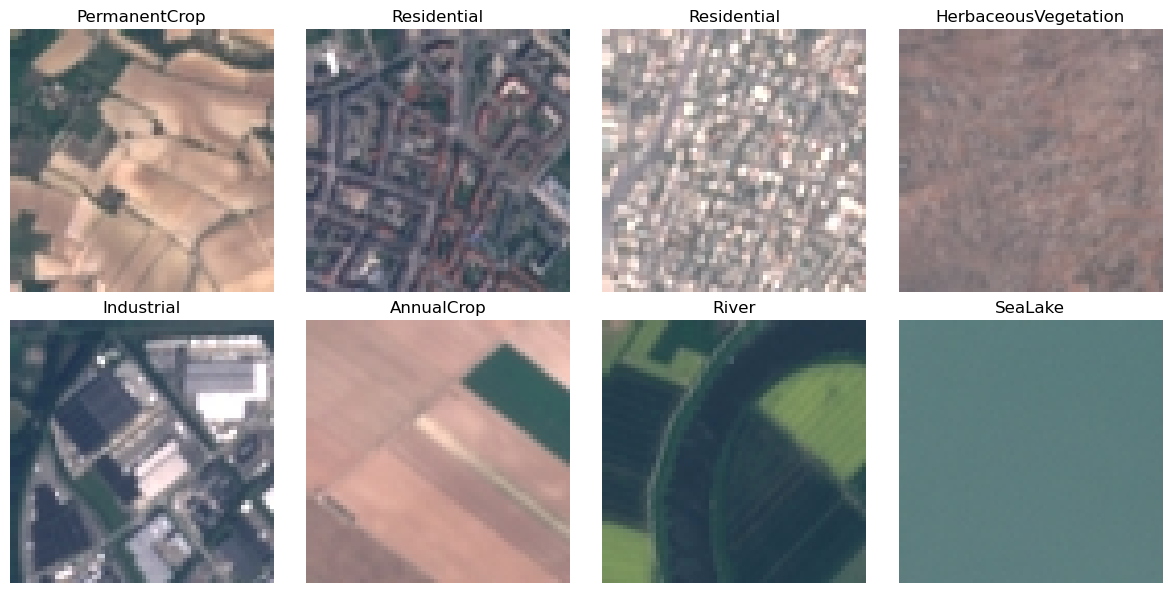

In [15]:
classes = loader_info["classes"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()

    # desnormalizar para visualizar cuando usamos mean=std=0.5
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Observaciones iniciales

- El dataset EuroSAT se ha cargado correctamente mediante `ImageFolder`.
- Se han identificado 10 clases.
- Para las primeras pruebas se ha creado un subconjunto balanceado de 1000 imágenes por clase.
- Las particiones train/validation/test se han generado de forma estratificada y se han guardado en un archivo JSON para garantizar reproducibilidad y reutilización en notebooks posteriores.
- Se ha verificado que los `DataLoader` funcionan correctamente y generan batches con forma `(batch_size, 3, 64, 64)`.